In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [14]:
#Import the data set
titanic_data = pd.read_csv('titanic_train.csv')

In [15]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<AxesSubplot:xlabel='Survived', ylabel='count'>

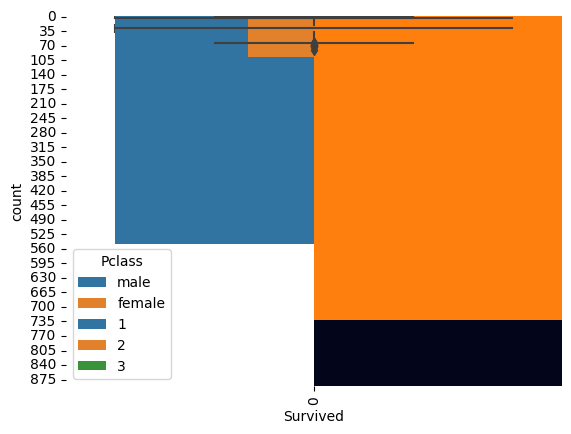

In [20]:
#Exploratory data analysis
sns.heatmap(titanic_data.isnull(), cbar=False)
sns.countplot(x='Survived', data=titanic_data)
sns.countplot(x='Survived', hue='Sex', data=titanic_data)
sns.countplot(x='Survived', hue='Pclass', data=titanic_data)
#sns.countplot(x='Survived', hue='Age', data=titanic_data)
plt.hist(titanic_data['Age'].dropna())
plt.hist(titanic_data['Fare'])
sns.boxplot(titanic_data['Pclass'])
sns.boxplot(titanic_data['Age'])

In [21]:
#Imputation function
def impute_missing_age(columns):
    age = columns[0]
    passenger_class = columns[1]
    
    if pd.isnull(age):
        if(passenger_class == 1):
            return titanic_data[titanic_data['Pclass'] == 1]['Age'].mean()
        elif(passenger_class == 2):
            return titanic_data[titanic_data['Pclass'] == 2]['Age'].mean()
        elif(passenger_class == 3):
            return titanic_data[titanic_data['Pclass'] == 3]['Age'].mean()
        
    else:
        return age

<AxesSubplot:>

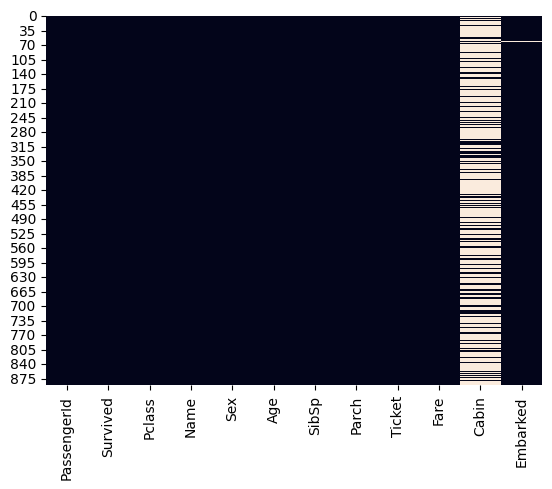

In [22]:
#Impute the missing Age data
titanic_data['Age'] = titanic_data[['Age', 'Pclass']].apply(impute_missing_age, axis = 1)

#Reinvestigate missing data
sns.heatmap(titanic_data.isnull(), cbar=False)

In [23]:
#Drop null data
titanic_data.drop('Cabin', axis=1, inplace = True)
titanic_data.dropna(inplace = True)

In [24]:
#Create dummy variables for Sex and Embarked columns
sex_data = pd.get_dummies(titanic_data['Sex'], drop_first = True)
embarked_data = pd.get_dummies(titanic_data['Embarked'], drop_first = True)

In [25]:
#Add dummy variables to the DataFrame and drop non-numeric data
titanic_data = pd.concat([titanic_data, sex_data, embarked_data], axis = 1)
titanic_data.drop(['Name', 'PassengerId', 'Ticket', 'Sex', 'Embarked'], axis = 1, inplace = True)

In [26]:
#Print the finalized data set
titanic_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


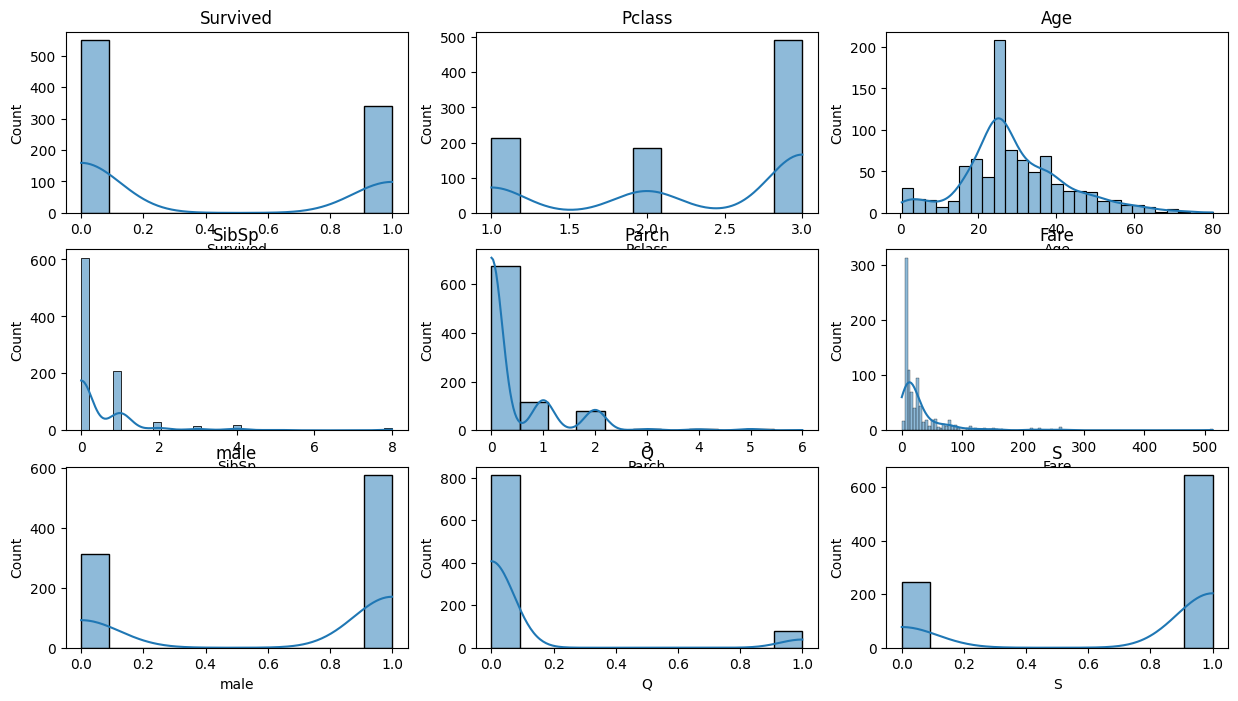

In [37]:
x=1
plt.figure(figsize=(15,8))
for i in titanic_data.columns:

    plt.subplot(3,3,x)
    sns.histplot(titanic_data[i],kde=True)
    plt.title('{0}'.format(i))
    x+=1

In [27]:
#Split the data set into x and y data
y_data = titanic_data['Survived']
x_data = titanic_data.drop('Survived', axis = 1)

In [44]:
#Split the data set into training data and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.3)


In [45]:
lr=LogisticRegression()

lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)

c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\sklearn\linear_model\_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [31]:
#Calculate performance metrics
from sklearn.metrics import classification_report
print(classification_report(y_test_data, predictions))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       160
           1       0.77      0.67      0.72       107

    accuracy                           0.79       267
   macro avg       0.79      0.77      0.78       267
weighted avg       0.79      0.79      0.79       267



<AxesSubplot:>

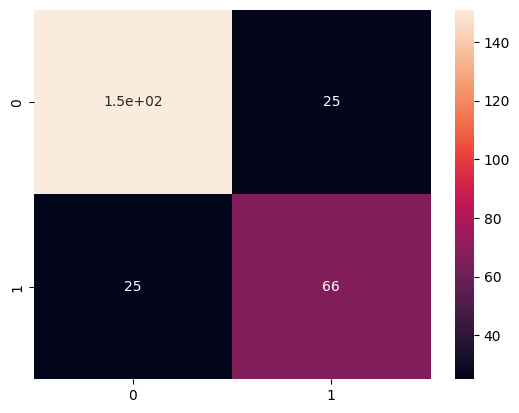

In [50]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
from sklearn.model_selection import train_test_split

In [52]:
y_predprob=lr.predict_proba(x_test)
y_predprob[:10]

array([[0.32399095, 0.67600905],
       [0.2761195 , 0.7238805 ],
       [0.9677973 , 0.0322027 ],
       [0.3379305 , 0.6620695 ],
       [0.22230062, 0.77769938],
       [0.8664276 , 0.1335724 ],
       [0.83133465, 0.16866535],
       [0.07305179, 0.92694821],
       [0.16808463, 0.83191537],
       [0.79544113, 0.20455887]])

In [53]:
fpr,tpr,threshold = roc_curve(y_test,y_predprob[:,1])

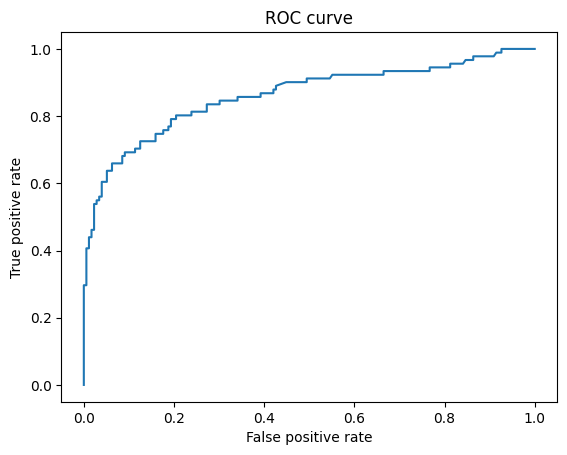

In [54]:
plt.plot(fpr,tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.savefig('ROC_curve.png')

In [55]:
auc(fpr,tpr)

0.8613573926073926